In [41]:
pip install pandas numpy matplotlib seaborn plotly scikit-learn shap

In [42]:
#  SECTION 1 · IMPORTS & SETUP

In [43]:
import pandas as pd

In [44]:
import numpy as np

In [45]:
import matplotlib.pyplot as plt

In [46]:
import seaborn as sns

In [47]:
import plotly.express as px

In [48]:
import warnings

In [49]:
warnings.filterwarnings("ignore")

In [50]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold

In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
from sklearn.preprocessing import LabelEncoder

In [53]:
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)

In [54]:
import shap

In [55]:
# Consistent style for all matplotlib plots
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
SEED = 42

In [56]:
#  SECTION 2 · LOAD DATA

In [57]:
df = pd.read_csv("global_air_pollution_data.csv")
df.columns = df.columns.str.strip().str.lower()

In [58]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget — AQI Value stats:\n{df['aqi_value'].describe()}")

DATASET OVERVIEW
Shape            : 23,463 rows × 12 columns

Columns:
['country_name', 'city_name', 'aqi_value', 'aqi_category', 'co_aqi_value', 'co_aqi_category', 'ozone_aqi_value', 'ozone_aqi_category', 'no2_aqi_value', 'no2_aqi_category', 'pm2.5_aqi_value', 'pm2.5_aqi_category']

Data types:
country_name          object
city_name             object
aqi_value              int64
aqi_category          object
co_aqi_value           int64
co_aqi_category       object
ozone_aqi_value        int64
ozone_aqi_category    object
no2_aqi_value          int64
no2_aqi_category      object
pm2.5_aqi_value        int64
pm2.5_aqi_category    object
dtype: object

Missing values:
country_name          427
city_name               1
aqi_value               0
aqi_category            0
co_aqi_value            0
co_aqi_category         0
ozone_aqi_value         0
ozone_aqi_category      0
no2_aqi_value           0
no2_aqi_category        0
pm2.5_aqi_value         0
pm2.5_aqi_category      0
dtype: int64

In [59]:
#  SECTION 3 · DATA CLEANING

In [60]:
print("\n" + "=" * 55)
print("CLEANING")
print("=" * 55)



CLEANING


In [61]:
before = len(df)
df.dropna(subset=["aqi_value"], inplace=True)
print(f"Dropped {before - len(df)} rows with missing AQI Value")

Dropped 0 rows with missing AQI Value


In [62]:
df = df[(df["aqi_value"] >= 0) & (df["aqi_value"] <= 500)]
print(f"Rows after sensor-error filter : {len(df):,}")

Rows after sensor-error filter : 23,463


In [63]:
df.drop_duplicates(subset=["country_name", "city_name"], keep="first", inplace=True)
print(f"Rows after deduplication       : {len(df):,}")

Rows after deduplication       : 23,463


In [64]:
df.columns = (df.columns
                .str.strip()
                .str.replace(" ", "_")
                .str.lower())

print(f"\nCleaned columns:\n{df.columns.tolist()}")


Cleaned columns:
['country_name', 'city_name', 'aqi_value', 'aqi_category', 'co_aqi_value', 'co_aqi_category', 'ozone_aqi_value', 'ozone_aqi_category', 'no2_aqi_value', 'no2_aqi_category', 'pm2.5_aqi_value', 'pm2.5_aqi_category']


In [65]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f"\nRemaining nulls after fill:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Remaining nulls after fill:
country_name    427
city_name         1
dtype: int64


In [66]:
print("\n" + "=" * 55)
print("FEATURE ENGINEERING")
print("=" * 55)


FEATURE ENGINEERING


In [67]:
aqi_order = {
    "Good": 0,
    "Moderate": 1,
    "Unhealthy for Sensitive Groups": 2,
    "Unhealthy": 3,
    "Very Unhealthy": 4,
    "Hazardous": 5,
}
df["aqi_category_num"] = df["aqi_category"].map(aqi_order)

In [68]:
pollutant_cols = ["co_aqi_value", "ozone_aqi_value",
                  "no2_aqi_value", "pm2.5_aqi_value"]
df["dominant_pollutant"] = df[pollutant_cols].idxmax(axis=1)
df["dominant_pollutant"] = (df["dominant_pollutant"]
                             .str.replace("_aqi_value", "")
                             .str.upper())


In [69]:
df["pollutant_spread"] = (df[pollutant_cols].max(axis=1)
                          - df[pollutant_cols].min(axis=1))

In [70]:
df["mean_pollutant_aqi"] = df[pollutant_cols].mean(axis=1)

In [71]:
df["pm25_ratio"] = df["pm2.5_aqi_value"] / (df["aqi_value"] + 1)

In [73]:
le = LabelEncoder()
df["country_enc"] = le.fit_transform(df["country_name"].astype(str))

print("New features created:")
new_feats = ["aqi_category_num", "dominant_pollutant",
             "pollutant_spread", "mean_pollutant_aqi",
             "pm25_ratio", "country_enc"]
print(df[new_feats].head())
print(f"\nTop dominant pollutants:\n{df['dominant_pollutant'].value_counts()}")


New features created:
   aqi_category_num dominant_pollutant  pollutant_spread  mean_pollutant_aqi  \
0                 1              PM2.5                51               22.00   
1                 0              PM2.5                40               12.00   
2                 1              PM2.5                65               27.00   
3                 0              OZONE                34               13.75   
4                 0              OZONE                22                7.00   

   pm25_ratio  country_enc  
0    0.980769          130  
1    0.976190           22  
2    0.985075           75  
3    0.571429          123  
4    0.260870           54  

Top dominant pollutants:
dominant_pollutant
PM2.5    18276
OZONE     5186
NO2          1
Name: count, dtype: int64


In [74]:
print("\n" + "=" * 55)
print("EDA")
print("=" * 55)


EDA


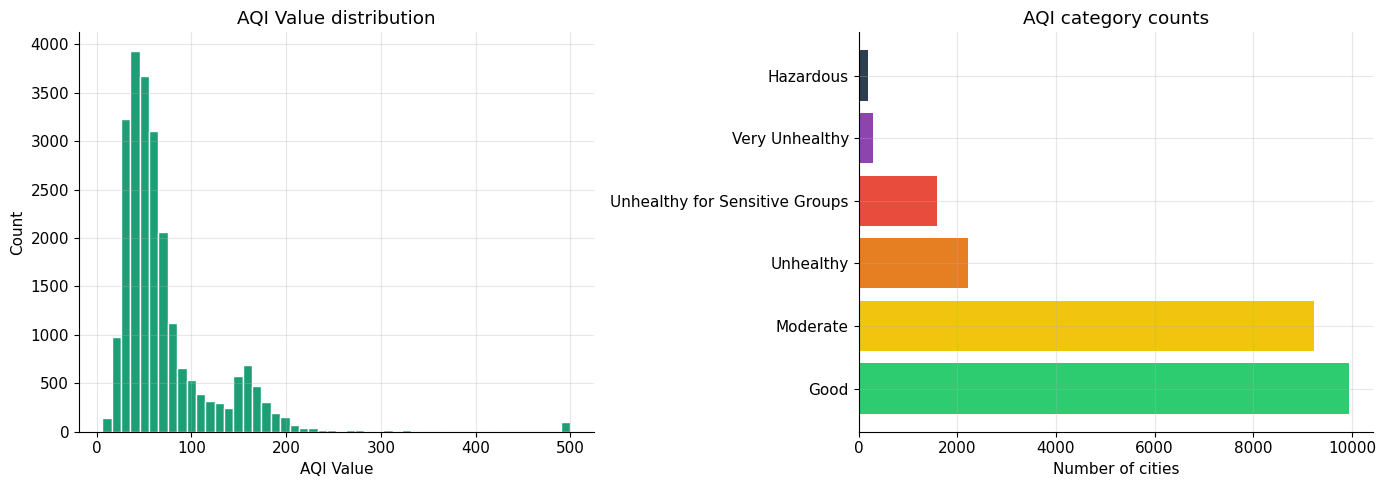

Saved: eda_01_aqi_distribution.png


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["aqi_value"], bins=50, color="#1D9E75", edgecolor="white")
axes[0].set_title("AQI Value distribution")
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Count")

category_counts = df["aqi_category"].value_counts()
axes[1].barh(category_counts.index, category_counts.values,
             color=["#2ecc71","#f1c40f","#e67e22","#e74c3c","#8e44ad","#2c3e50"])
axes[1].set_title("AQI category counts")
axes[1].set_xlabel("Number of cities")

plt.tight_layout()
plt.savefig("eda_01_aqi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_01_aqi_distribution.png")

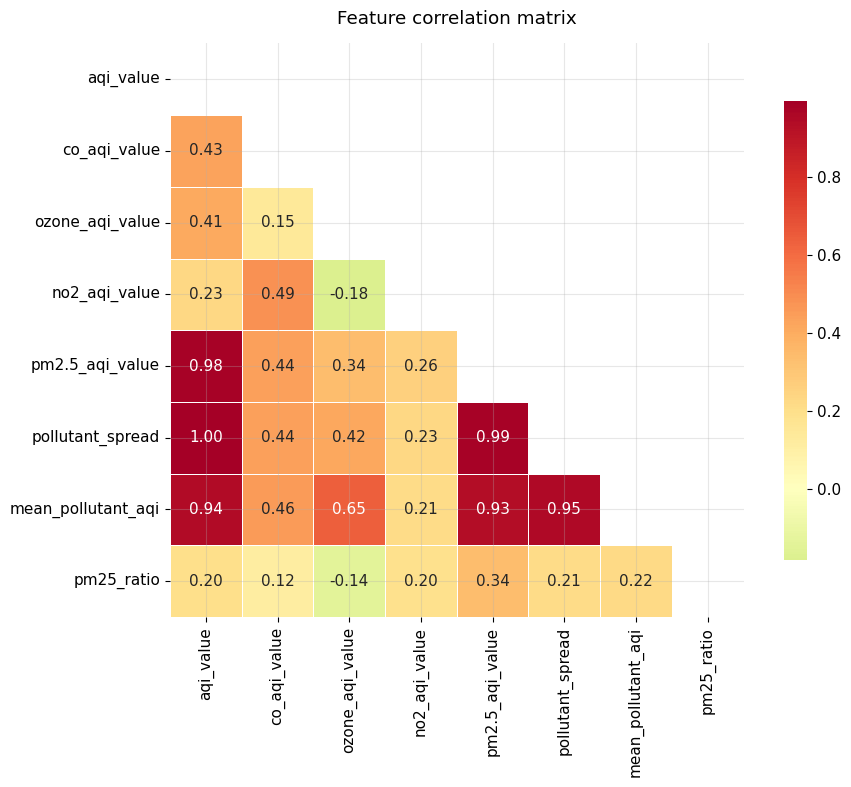

Saved: eda_02_correlation.png


In [77]:
numeric_df = df[["aqi_value", "co_aqi_value", "ozone_aqi_value",
                  "no2_aqi_value", "pm2.5_aqi_value",
                  "pollutant_spread", "mean_pollutant_aqi",
                  "pm25_ratio"]].copy()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn_r", center=0, ax=ax,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix", pad=14)
plt.tight_layout()
plt.savefig("eda_02_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_02_correlation.png")

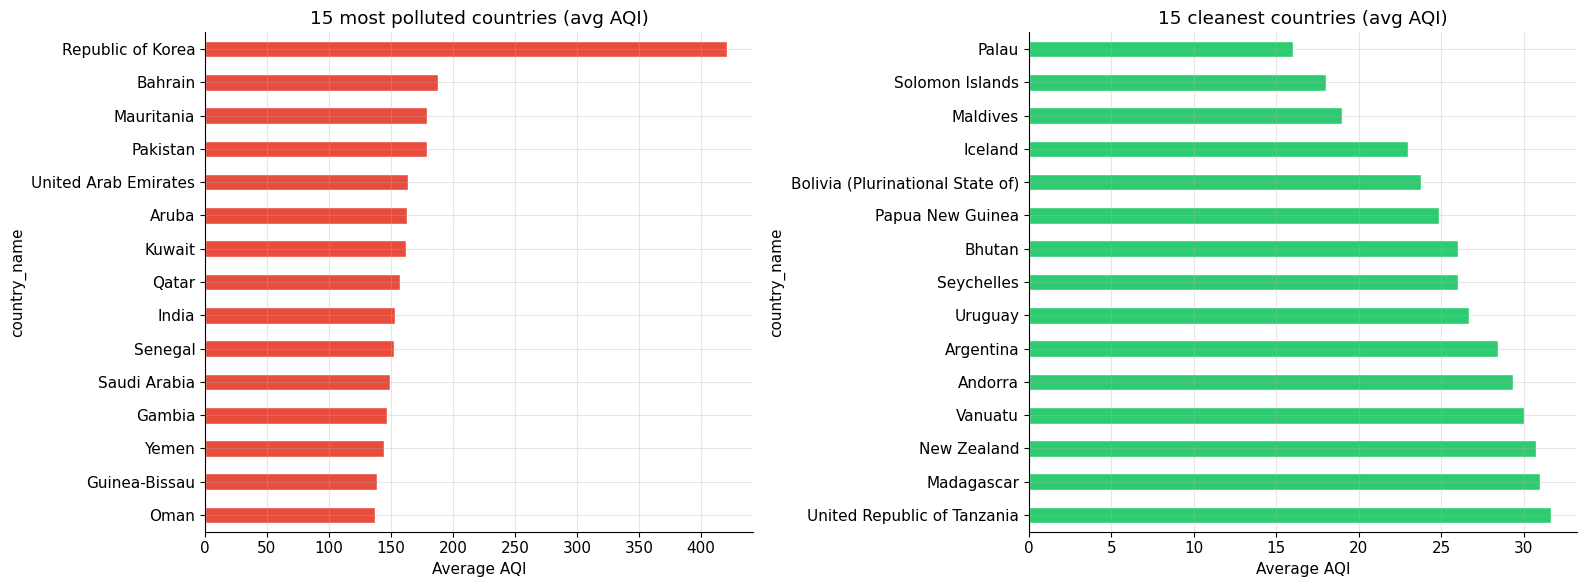

Saved: eda_03_country_rankings.png


In [79]:
country_avg = (df.groupby("country_name")["aqi_value"]
                 .mean()
                 .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

country_avg.head(15).plot(kind="barh", ax=axes[0],
                           color="#e74c3c", edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_title("15 most polluted countries (avg AQI)")
axes[0].set_xlabel("Average AQI")

country_avg.tail(15).plot(kind="barh", ax=axes[1],
                           color="#2ecc71", edgecolor="white")
axes[1].set_title("15 cleanest countries (avg AQI)")
axes[1].set_xlabel("Average AQI")

plt.tight_layout()
plt.savefig("eda_03_country_rankings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_03_country_rankings.png")

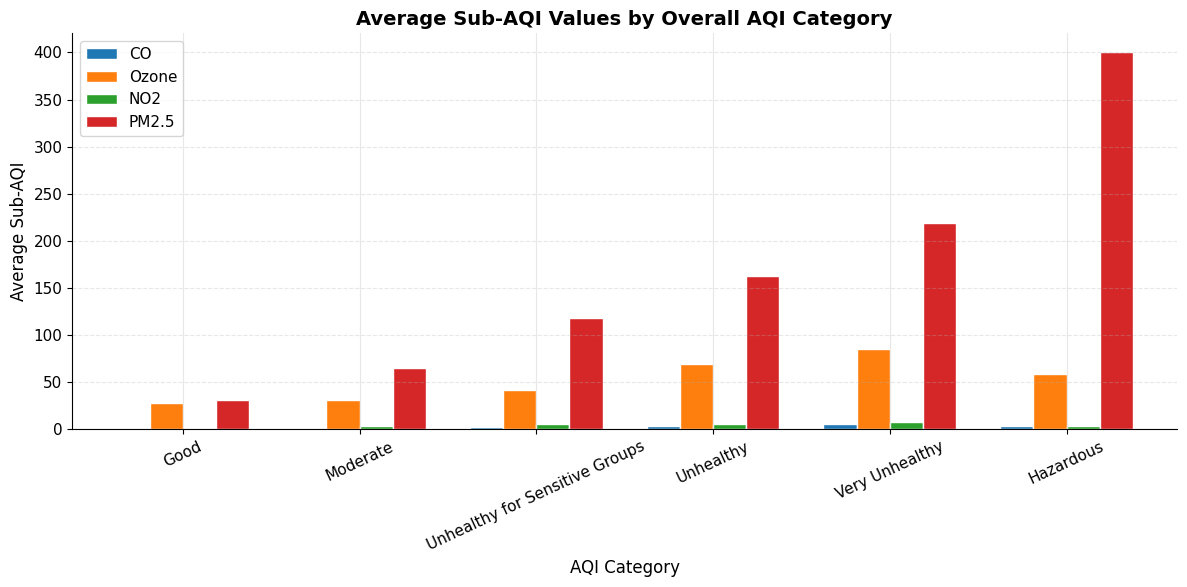

🎉 Saved: eda_04_pollutant_breakdown.png


In [81]:
import matplotlib.pyplot as plt

# 1. Define the missing pollutant column names (using our clean lowercase versions)
pollutant_cols = ['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']

# 2. Define the exact categorical ordering specified in your project plan (Image 2)
aqi_order = {
    'Good': 0,
    'Moderate': 1,
    'Unhealthy for Sensitive Groups': 2, # Common standard category name in this dataset
    'Unhealthy': 3,
    'Very Unhealthy': 4,
    'Hazardous': 5
}

# 3. Compute the means safely, matching only the categories that exist in your dataset
available_categories = [cat for cat in aqi_order.keys() if cat in df['aqi_category'].unique()]

pollutant_by_cat = (df.groupby("aqi_category")[pollutant_cols]
                    .mean()
                    .reindex(available_categories))

# 4. Plot the breakdown
fig, ax = plt.subplots(figsize=(12, 6))
pollutant_by_cat.plot(kind="bar", ax=ax, width=0.75, edgecolor="white")

ax.set_title("Average Sub-AQI Values by Overall AQI Category", fontsize=14, fontweight='bold')
ax.set_xlabel("AQI Category", fontsize=12)
ax.set_ylabel("Average Sub-AQI", fontsize=12)
ax.legend(["CO", "Ozone", "NO2", "PM2.5"], loc="upper left")
ax.tick_params(axis="x", rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("eda_04_pollutant_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

print("🎉 Saved: eda_04_pollutant_breakdown.png")

In [83]:
country_map = df.groupby("country_name")["aqi_value"].mean().reset_index()
country_map.columns = ["country", "avg_aqi"]

fig = px.choropleth(
    country_map,
    locations="country",
    locationmode="country names",
    color="avg_aqi",
    color_continuous_scale=["#2ecc71","#f1c40f","#e67e22","#e74c3c"],
    range_color=(0, 200),
    title="Average AQI by Country",
    labels={"avg_aqi": "Avg AQI"},
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(
        title="AQI",
        tickvals=[0, 50, 100, 150, 200],
        ticktext=["Good", "Moderate", "USG", "Unhealthy", "Very Unhealthy"],
    ),
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
)
fig.write_html("eda_05_world_aqi_map.html")
fig.show()
print("Saved: eda_05_world_aqi_map.html  (interactive)")


Saved: eda_05_world_aqi_map.html  (interactive)


In [84]:
print("\n" + "=" * 55)
print("MODEL PREPARATION")
print("=" * 55)


MODEL PREPARATION


In [85]:
FEATURES = [
    "co_aqi_value",
    "ozone_aqi_value",
    "no2_aqi_value",
    "pm2.5_aqi_value",
    "pollutant_spread",
    "mean_pollutant_aqi",
    "pm25_ratio",
    "aqi_category_num",
    "country_enc",
]
TARGET = "aqi_value"

In [86]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

In [87]:
print(f"Feature matrix : {X.shape}")
print(f"Target vector  : {y.shape}")
print(f"\nFeatures used  :\n{FEATURES}")


Feature matrix : (23463, 9)
Target vector  : (23463,)

Features used  :
['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value', 'pollutant_spread', 'mean_pollutant_aqi', 'pm25_ratio', 'aqi_category_num', 'country_enc']


In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain rows : {len(X_train):,}   Test rows : {len(X_test):,}")



Train rows : 18,770   Test rows : 4,693


In [89]:
print("\n" + "=" * 55)
print("RANDOM FOREST — TRAINING")
print("=" * 55)


RANDOM FOREST — TRAINING


In [90]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [91]:
y_pred = rf.predict(X_test)

In [92]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

In [93]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2", n_jobs=-1)

print(f"\n{'Metric':<28} {'Value':>10}")
print("-" * 40)
print(f"{'MAE':<28} {mae:>10.2f}")
print(f"{'RMSE':<28} {rmse:>10.2f}")
print(f"{'R² (test)':<28} {r2:>10.4f}")
print(f"{'R² (5-fold CV mean)':<28} {cv_scores.mean():>10.4f}")
print(f"{'R² (5-fold CV std)':<28} {cv_scores.std():>10.4f}")


Metric                            Value
----------------------------------------
MAE                                0.11
RMSE                               1.52
R² (test)                        0.9993
R² (5-fold CV mean)              0.9994
R² (5-fold CV std)               0.0003


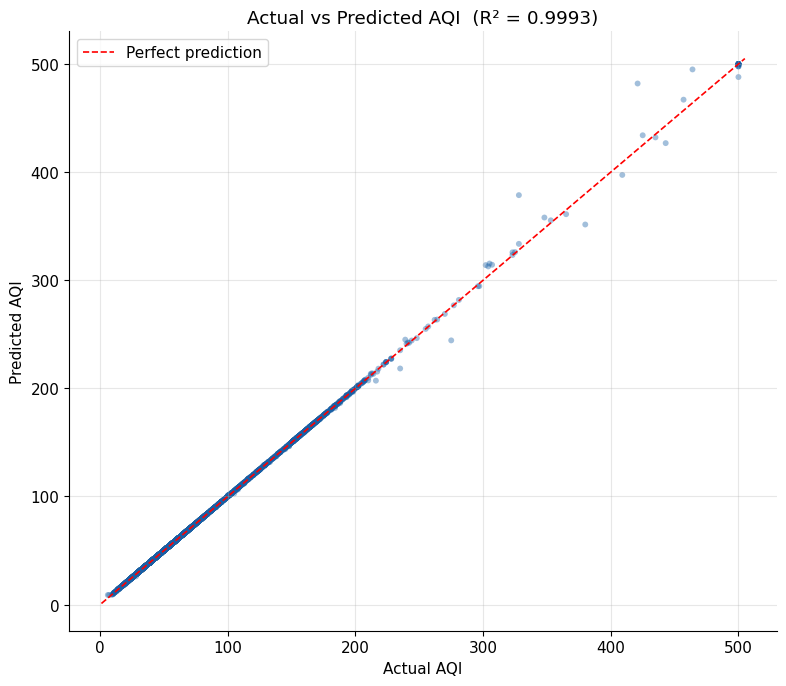


Saved: model_01_actual_vs_predicted.png


In [94]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, y_pred, alpha=0.4, s=18, color="#185FA5", edgecolors="none")
lims = [min(y_test.min(), y_pred.min()) - 5,
        max(y_test.max(), y_pred.max()) + 5]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect prediction")
ax.set_xlabel("Actual AQI")
ax.set_ylabel("Predicted AQI")
ax.set_title(f"Actual vs Predicted AQI  (R² = {r2:.4f})")
ax.legend()
plt.tight_layout()
plt.savefig("model_01_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: model_01_actual_vs_predicted.png")


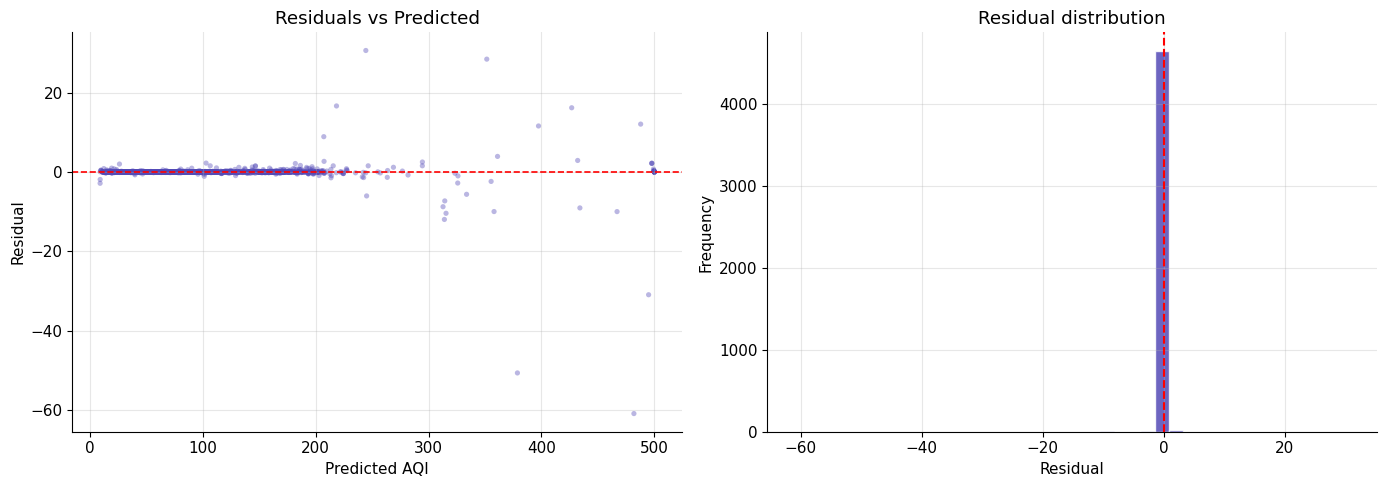

Saved: model_02_residuals.png


In [95]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.4, s=14,
                color="#534AB7", edgecolors="none")
axes[0].axhline(0, color="red", linewidth=1.2, linestyle="--")
axes[0].set_xlabel("Predicted AQI")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, color="#534AB7",
             edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.savefig("model_02_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_02_residuals.png")

In [96]:
print("\n" + "=" * 55)
print("FEATURE IMPORTANCE")
print("=" * 55)


FEATURE IMPORTANCE


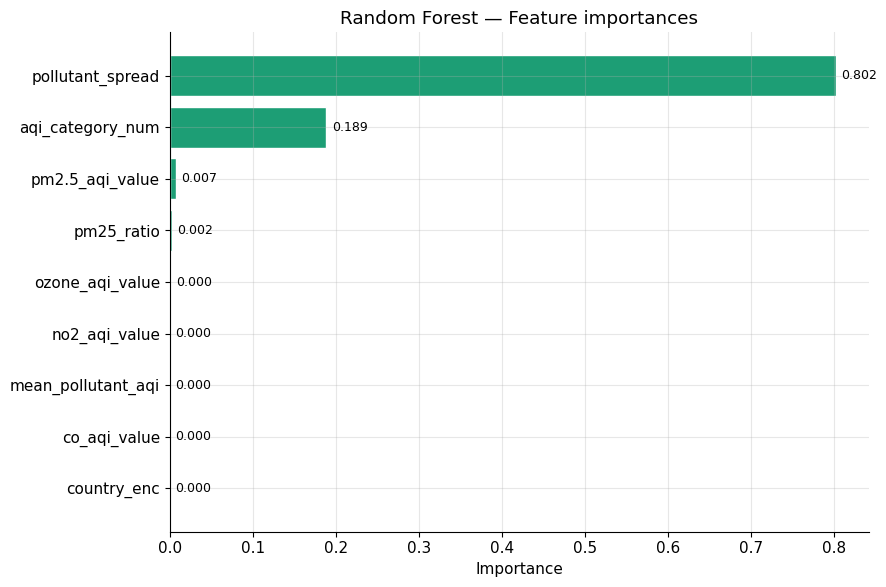

Saved: model_03_feature_importance.png
           feature  importance
  pollutant_spread    0.801988
  aqi_category_num    0.188549
   pm2.5_aqi_value    0.006900
        pm25_ratio    0.002115
   ozone_aqi_value    0.000172
     no2_aqi_value    0.000098
mean_pollutant_aqi    0.000069
      co_aqi_value    0.000060
       country_enc    0.000049


In [97]:

importance_df = (pd.DataFrame({
                    "feature": FEATURES,
                    "importance": rf.feature_importances_
                 })
                 .sort_values("importance", ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df["feature"], importance_df["importance"],
               color="#1D9E75", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.set_title("Random Forest — Feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("model_03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_03_feature_importance.png")
print(importance_df.sort_values("importance", ascending=False).to_string(index=False))

In [98]:
print("\n" + "=" * 55)
print("SHAP ANALYSIS")
print("=" * 55)


SHAP ANALYSIS


In [99]:
X_shap = X_test.sample(min(300, len(X_test)), random_state=SEED)

In [100]:
print("Computing SHAP values (Tree explainer)...")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape : {np.array(shap_values).shape}")

Computing SHAP values (Tree explainer)...
SHAP values shape : (300, 9)


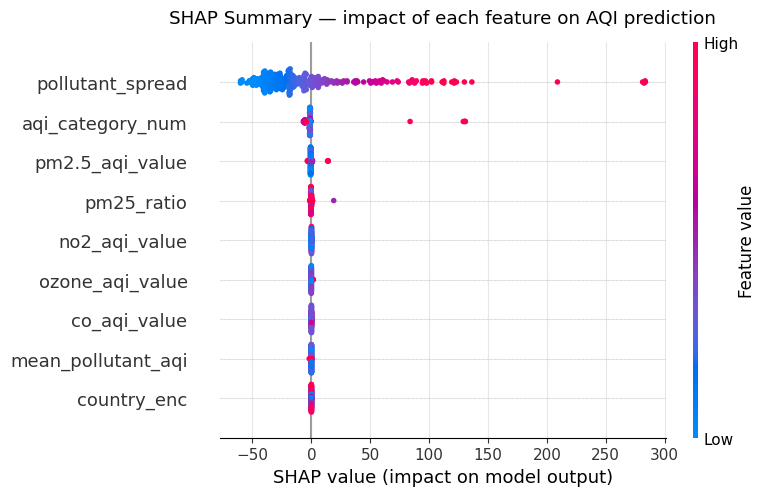

Saved: shap_01_summary_beeswarm.png


In [101]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap,
                  feature_names=FEATURES,
                  plot_type="dot",
                  show=False)
plt.title("SHAP Summary — impact of each feature on AQI prediction", pad=14)
plt.tight_layout()
plt.savefig("shap_01_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_01_summary_beeswarm.png")

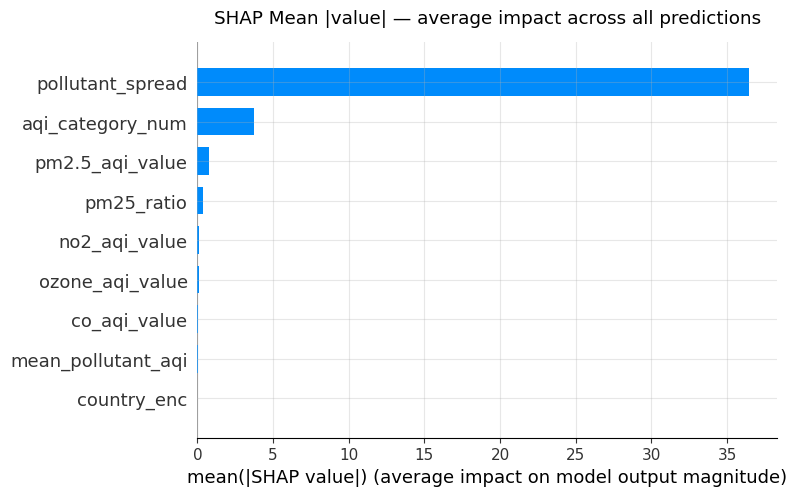

Saved: shap_02_bar.png


In [102]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_shap,
                  feature_names=FEATURES,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Mean |value| — average impact across all predictions", pad=14)
plt.tight_layout()
plt.savefig("shap_02_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_02_bar.png")

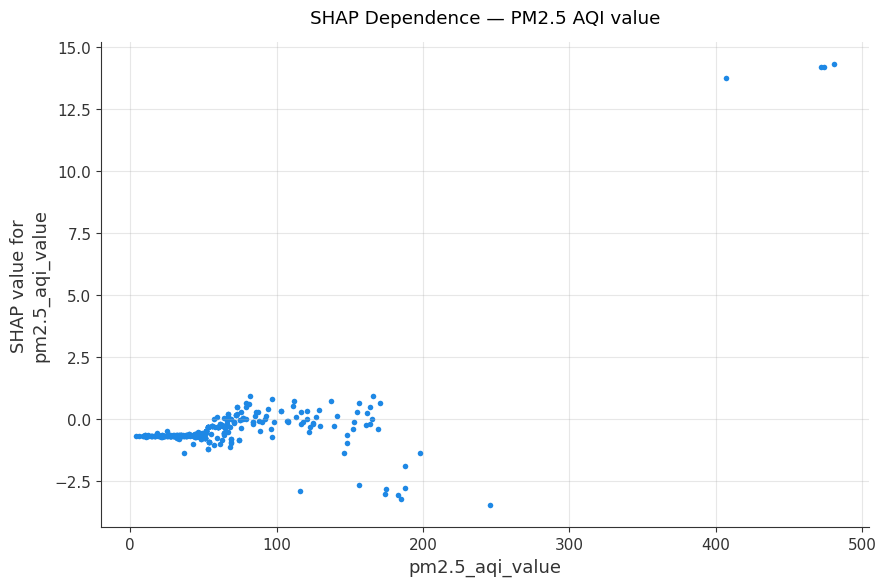

Saved: shap_03_dependence_pm25.png


In [103]:
fig, ax = plt.subplots(figsize=(9, 6))
pm25_idx = FEATURES.index("pm2.5_aqi_value")
shap.dependence_plot(
    pm25_idx,
    shap_values,
    X_shap,
    feature_names=FEATURES,
    interaction_index=None,
    ax=ax,
    show=False,
)
ax.set_title("SHAP Dependence — PM2.5 AQI value", pad=14)
plt.tight_layout()
plt.savefig("shap_03_dependence_pm25.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_03_dependence_pm25.png")

In [104]:
worst_idx = np.argmax(y_pred)
print(f"\nExplaining prediction for sample index {worst_idx}")
print(f"  Actual AQI    : {y_test.iloc[worst_idx]:.1f}")
print(f"  Predicted AQI : {y_pred[worst_idx]:.1f}")



Explaining prediction for sample index 51
  Actual AQI    : 500.0
  Predicted AQI : 500.0


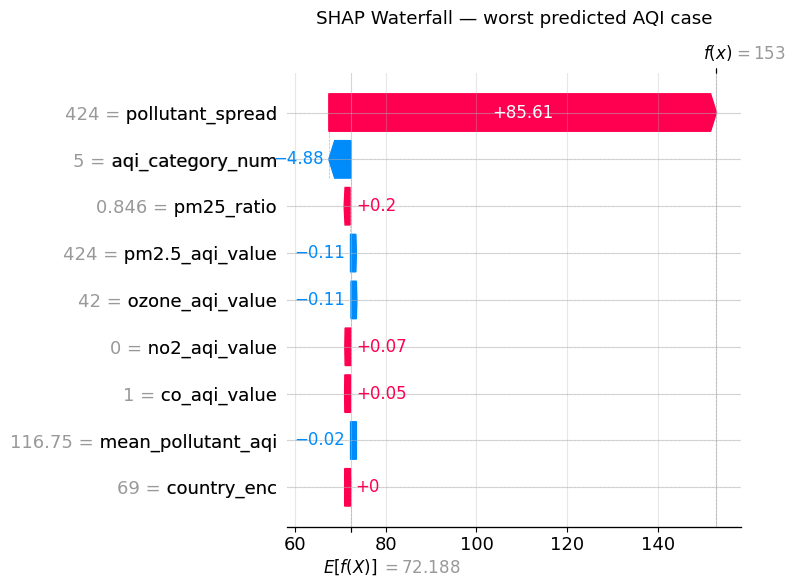

Saved: shap_04_waterfall_single.png


In [105]:
exp = shap.Explanation(
    values=shap_values[worst_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[worst_idx].values,
    feature_names=FEATURES,
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(exp, show=False)
plt.title("SHAP Waterfall — worst predicted AQI case", pad=14)
plt.tight_layout()
plt.savefig("shap_04_waterfall_single.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_04_waterfall_single.png")

In [106]:
print("\n" + "=" * 55)
print("POLICY SIMULATOR")
print("=" * 55)


POLICY SIMULATOR


In [107]:
def simulate_reduction(pollutant: str, reduction_pct: float) -> dict:
    """
    Simulate reducing one pollutant by reduction_pct % across all
    test cities and return average predicted AQI before and after.
    """
    X_sim = X_test.copy()
    X_sim[pollutant] = X_sim[pollutant] * (1 - reduction_pct / 100)

    before = rf.predict(X_test).mean()
    after  = rf.predict(X_sim).mean()
    delta  = before - after

    return {
        "pollutant"    : pollutant,
        "reduction_pct": reduction_pct,
        "avg_aqi_before": round(before, 2),
        "avg_aqi_after" : round(after, 2),
        "avg_aqi_drop"  : round(delta, 2),
    }


scenarios = []
for pollutant in pollutant_cols:
    for pct in [10, 25, 50]:
        scenarios.append(simulate_reduction(pollutant, pct))

sim_df = pd.DataFrame(scenarios)
print(sim_df.to_string(index=False))

      pollutant  reduction_pct  avg_aqi_before  avg_aqi_after  avg_aqi_drop
   co_aqi_value             10           71.21          71.21          0.00
   co_aqi_value             25           71.21          71.21          0.00
   co_aqi_value             50           71.21          71.07          0.14
ozone_aqi_value             10           71.21          71.12          0.09
ozone_aqi_value             25           71.21          71.12          0.09
ozone_aqi_value             50           71.21          71.11          0.10
  no2_aqi_value             10           71.21          71.21          0.00
  no2_aqi_value             25           71.21          71.21          0.00
  no2_aqi_value             50           71.21          71.15          0.06
pm2.5_aqi_value             10           71.21          70.37          0.85
pm2.5_aqi_value             25           71.21          70.16          1.06
pm2.5_aqi_value             50           71.21          70.11          1.10


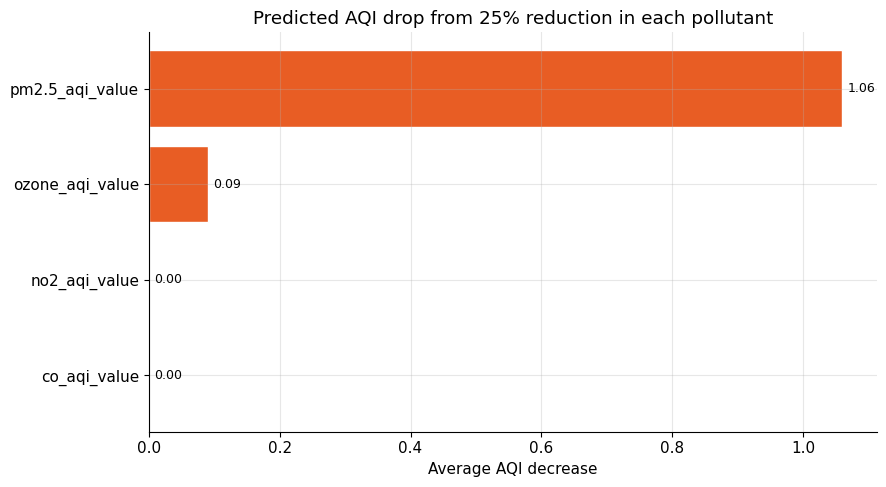

Saved: policy_simulator.png


In [108]:
at_25 = sim_df[sim_df["reduction_pct"] == 25].sort_values("avg_aqi_drop",
                                                           ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(at_25["pollutant"], at_25["avg_aqi_drop"],
               color="#E85D24", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_title("Predicted AQI drop from 25% reduction in each pollutant")
ax.set_xlabel("Average AQI decrease")
plt.tight_layout()
plt.savefig("policy_simulator.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: policy_simulator.png")

In [ ]:
print("\n" + "=" * 55)
print("CITY HEALTH RISK REPORT")
print("=" * 55)

In [112]:
report_df = df.loc[X_test.index, ["country_name", "city_name",
                                   "aqi_value", "aqi_category",
                                   "dominant_pollutant"]].copy()
report_df["predicted_aqi"] = y_pred.round(1)
report_df["error"]         = (report_df["aqi_value"]
                               - report_df["predicted_aqi"]).abs().round(1)
report_df["risk_level"] = pd.cut(
    report_df["predicted_aqi"],
    bins=[0, 50, 100, 150, 200, 300, 500],
    labels=["Good", "Moderate", "Unhealthy (Sensitive)",
            "Unhealthy", "Very Unhealthy", "Hazardous"],
)

print("\n🔥 Top 10 highest-risk cities (by predicted AQI):")
# FIXED: Changed 'country' to 'country_name' and 'city' to 'city_name'
top10 = (report_df.sort_values("predicted_aqi", ascending=False)
                  .head(10)
                  [["country_name", "city_name", "predicted_aqi",
                    "risk_level", "dominant_pollutant"]])
print(top10.to_string(index=False))

print("\n🍃 10 safest cities (by predicted AQI):")
# FIXED: Changed 'country' to 'country_name' and 'city' to 'city_name'
bot10 = (report_df.sort_values("predicted_aqi")
                  .head(10)
                  [["country_name", "city_name", "predicted_aqi",
                    "risk_level", "dominant_pollutant"]])
print(bot10.to_string(index=False))

# Save the full report
report_df.to_csv("city_health_risk_report.csv", index=False)
print("\n🎉 Full report saved: city_health_risk_report.csv")


🔥 Top 10 highest-risk cities (by predicted AQI):
country_name  city_name  predicted_aqi risk_level dominant_pollutant
       India      Bagar          500.0  Hazardous              PM2.5
       India      Dhuri          500.0  Hazardous              PM2.5
       India Ganganagar          500.0  Hazardous              PM2.5
       India      Sunam          500.0  Hazardous              PM2.5
       India   Phalauda          500.0  Hazardous              PM2.5
       India    Narauli          500.0  Hazardous              PM2.5
       India  Suratgarh          500.0  Hazardous              PM2.5
       India     Siwani          500.0  Hazardous              PM2.5
       India   Gajraula          500.0  Hazardous              PM2.5
       India  Faridabad          500.0  Hazardous              PM2.5

🍃 10 safest cities (by predicted AQI):
                    country_name      city_name  predicted_aqi risk_level dominant_pollutant
Bolivia (Plurinational State of)       El Torno           

In [113]:
print("\n" + "=" * 55)
print("PIPELINE COMPLETE — SUMMARY")
print("=" * 55)
print(f"  Dataset rows          : {len(df):,}")
print(f"  Features used         : {len(FEATURES)}")
print(f"  MAE                   : {mae:.2f} AQI points")
print(f"  RMSE                  : {rmse:.2f} AQI points")
print(f"  R² (test)             : {r2:.4f}")
print(f"  R² (5-fold CV)        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
top_feat = importance_df.sort_values("importance", ascending=False).iloc[0]
print(f"  Top feature           : {top_feat['feature']} ({top_feat['importance']:.3f})")
top_pol  = at_25.sort_values("avg_aqi_drop", ascending=False).iloc[0]
print(f"  Biggest policy lever  : 25% cut in {top_pol['pollutant']} → "
      f"−{top_pol['avg_aqi_drop']:.2f} avg AQI")
print("\nOutput files:")
outputs = [
    "eda_01_aqi_distribution.png",
    "eda_02_correlation.png",
    "eda_03_country_rankings.png",
    "eda_04_pollutant_breakdown.png",
    "eda_05_world_aqi_map.html",
    "model_01_actual_vs_predicted.png",
    "model_02_residuals.png",
    "model_03_feature_importance.png",
    "shap_01_summary_beeswarm.png",
    "shap_02_bar.png",
    "shap_03_dependence_pm25.png",
    "shap_04_waterfall_single.png",
    "policy_simulator.png",
    "city_health_risk_report.csv",
]
for f in outputs:
    print(f"  • {f}")


PIPELINE COMPLETE — SUMMARY
  Dataset rows          : 23,463
  Features used         : 9
  MAE                   : 0.11 AQI points
  RMSE                  : 1.52 AQI points
  R² (test)             : 0.9993
  R² (5-fold CV)        : 0.9994 ± 0.0003
  Top feature           : pollutant_spread (0.802)
  Biggest policy lever  : 25% cut in pm2.5_aqi_value → −1.06 avg AQI

Output files:
  • eda_01_aqi_distribution.png
  • eda_02_correlation.png
  • eda_03_country_rankings.png
  • eda_04_pollutant_breakdown.png
  • eda_05_world_aqi_map.html
  • model_01_actual_vs_predicted.png
  • model_02_residuals.png
  • model_03_feature_importance.png
  • shap_01_summary_beeswarm.png
  • shap_02_bar.png
  • shap_03_dependence_pm25.png
  • shap_04_waterfall_single.png
  • policy_simulator.png
  • city_health_risk_report.csv


In [117]:
import zipfile
import os

# Define the name of your backup archive
zip_filename = "air_quality_project_backup.zip"

# List out all the precious pipeline outputs you want on your PC
files_to_save = [
    "eda_01_aqi_distribution.png",
    "eda_02_correlation.png",
    "eda_03_country_rankings.png",
    "eda_04_pollutant_breakdown.png",
    "eda_05_world_aqi_map.html",
    "model_01_actual_vs_predicted.png",
    "model_02_residuals.png",
    "model_03_feature_importance.png",
    "shap_01_summary_beeswarm.png",
    "shap_02_bar.png",
    "shap_03_dependence_pm25.png",
    "shap_04_waterfall_single.png",
    "policy_simulator.png",
    "city_health_risk_report.csv",
    "pipeline_summary_report.txt"  # The text log file from earlier
]

# Compress them into a single zip file
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_save:
        if os.path.exists(file):
            zipf.write(file)
            print(f"📦 Added to archive: {file}")
        else:
            print(f"⚠️ Warning: Could not find '{file}' in workspace.")

print(f"\n🎉 SUCCESS! Your complete package is ready: '{zip_filename}'")

📦 Added to archive: eda_01_aqi_distribution.png
📦 Added to archive: eda_02_correlation.png
📦 Added to archive: eda_03_country_rankings.png
📦 Added to archive: eda_04_pollutant_breakdown.png
📦 Added to archive: eda_05_world_aqi_map.html
📦 Added to archive: model_01_actual_vs_predicted.png
📦 Added to archive: model_02_residuals.png
📦 Added to archive: model_03_feature_importance.png
📦 Added to archive: shap_01_summary_beeswarm.png
📦 Added to archive: shap_02_bar.png
📦 Added to archive: shap_03_dependence_pm25.png
📦 Added to archive: shap_04_waterfall_single.png
📦 Added to archive: policy_simulator.png
📦 Added to archive: city_health_risk_report.csv
📦 Added to archive: pipeline_summary_report.txt

🎉 SUCCESS! Your complete package is ready: 'air_quality_project_backup.zip'


In [118]:
from google.colab import files
files.download('air_quality_project_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>